# Let's fine out values needed for filtering    

Extracting EDF parameters from e:\WEBSITE\EDF_analysis\EDF+\Zacker\Zacker.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 139775  =      0.000 ...  1091.992 secs...
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Channel: Cz, Max Amplitude: 0.0004053760283822127, Mean Amplitude: 1.8081691416689617e-05
Channel: Fz, Max Amplitude: 0.000504347314249091, Mean Amplitude: 2.1159966250074288e-05
Channel: Fp1, Max Amplitude: 0.000692538598773157, Mean Amplitude: 8.792227597581204e-05
Channel: F7, Max Amplitude: 0.0002833205359660645, Mean Amplitude: 1.8827464466830574e-05
Channel: F3, Max Amplitude: 0.0006289508296151627, Mean Amplitude: 2.113676669122384e-05
Channel: FC1, Max Amplitude: 0.0004038376146122612, Mean Amplitude: 3.2998835073145126e-05
Channel: C3, Max Amplitude: 0.00030434552415540124, Mean Amplitude: 2.5372041926424155e-05
Channel: FC5, Max Amplitude: 0.0003966583503524877, Mean Amplitude: 1.

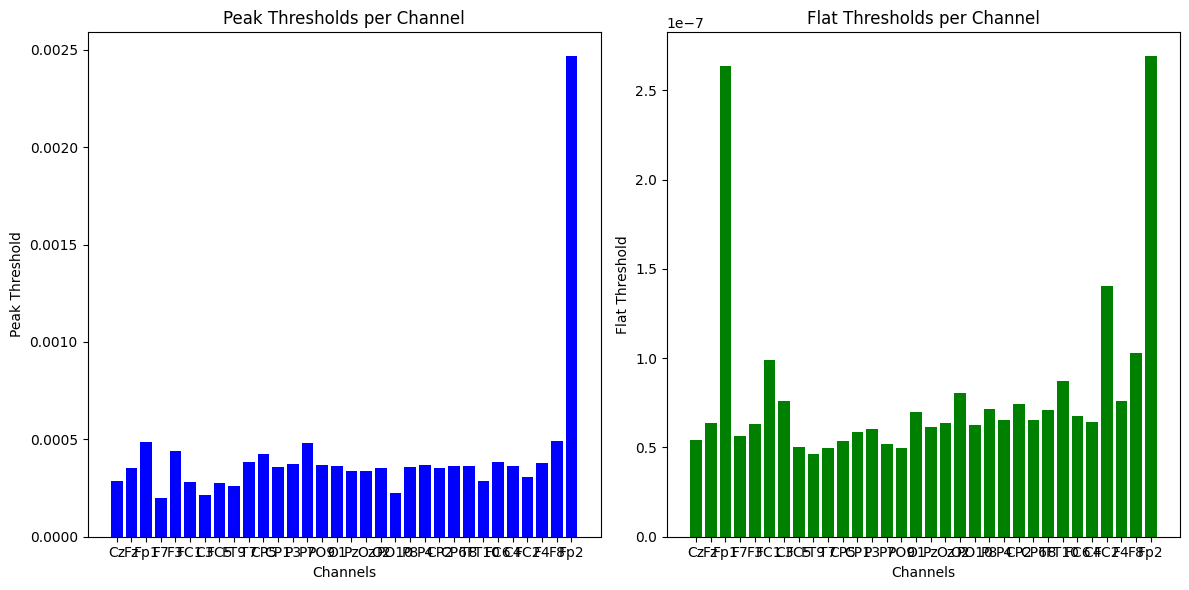

In [1]:
import mne
import numpy as np
import matplotlib.pyplot as plt

# Read your EDF file
raw = raw = mne.io.read_raw_edf(
    r'EDF+\254362\254362.edf',
    #eog=['Fp1', 'Fp2'], # Define eog channels!  I suggest trying making a copy of these as eog1 and eog2 ##NOTE: YOU MUST watch the capitalization!
    misc=None, # List of channel names to be considered as miscellaneous (MISC) channels.
    stim_channel=None,  # Set to None if you don't have a stim channel
    exclude=['TimestampS', 'TimestampMs', 'OrTimestampS', 'OrTimestampMs', 'Counter', 'Interpolated', 'HighBitFlex', 'SaturationFlag', 'RawCq', 'Battery', 'BatteryPercent', 'MarkerHardware', 'CQ.Cz', 'CQ.Fz', 'CQ.Fp1', 'CQ.F7', 'CQ.F3', 'CQ.FC1', 'CQ.C3', 'CQ.FC5', 'CQ.FT9', 'CQ.T7', 'CQ.CP5', 'CQ.CP1', 'CQ.P3', 'CQ.P7', 'CQ.PO9', 'CQ.O1', 'CQ.Pz', 'CQ.Oz', 'CQ.O2', 'CQ.PO10', 'CQ.P8', 'CQ.P4', 'CQ.CP2', 'CQ.CP6', 'CQ.T8', 'CQ.FT10', 'CQ.FC6', 'CQ.C4', 'CQ.FC2', 'CQ.F4', 'CQ.F8', 'CQ.Fp2', 'CQ.Overall', 'EQ.SampleRateQua', 'EQ.OVERALL', 'EQ.Cz', 'EQ.Fz', 'EQ.Fp1', 'EQ.F7', 'EQ.F3', 'EQ.FC1', 'EQ.C3', 'EQ.FC5', 'EQ.FT9', 'EQ.T7', 'EQ.CP5', 'EQ.CP1', 'EQ.P3', 'EQ.P7', 'EQ.PO9', 'EQ.O1', 'EQ.Pz', 'EQ.Oz', 'EQ.O2', 'EQ.PO10', 'EQ.P8', 'EQ.P4', 'EQ.CP2', 'EQ.CP6', 'EQ.T8', 'EQ.FT10', 'EQ.FC6', 'EQ.C4', 'EQ.FC2', 'EQ.F4', 'EQ.F8', 'EQ.Fp2', 'MOT.TimestampS', 'MOT.TimestampMs', 'MOT.OrTimestampS', 'MOT.OrTimestampM', 'MOT.CounterMems', 'MOT.Interpolated', 'MOT.Q0', 'MOT.Q1', 'MOT.Q2', 'MOT.Q3', 'MOT.AccX', 'MOT.AccY', 'MOT.AccZ', 'MOT.MagX', 'MOT.MagY', 'MOT.MagZ'],  # Exclude channels you don't want
    preload=True,  # Preload data into memory to speed things up
    infer_types=True,  # Infer channel types from names
    verbose=True  # Set verbosity / output messages
    )



# Select only EEG channels
eeg_channels = ['Cz', 'Fz', 'Fp1', 'F7', 'F3', 'FC1', 'C3', 'FC5', 'FT9', 'T7', 'CP5', 'CP1', 'P3', 'P7', 'PO9', 'O1', 'Pz', 'Oz', 'O2', 'PO10', 'P8', 'P4', 'CP2', 'CP6', 'T8', 'FT10', 'FC6', 'C4', 'FC2', 'F4', 'F8', 'Fp2']
raw.pick_channels(eeg_channels)

# Calculate amplitude statistics for each channel
peak_thresholds = {}
_thresholds = {}
for ch in eeg_channels:
    data = raw[ch][0]  # Get the data array for the channel
    max_value = np.max(np.abs(data))
    mean_value = np.mean(np.abs(data))
    
    # Set peak threshold as a fraction of max amplitude
    peak_threshold = max_value * 0.7  # Adjust multiplier based on your data characteristics
    peak_thresholds[ch] = peak_threshold
    
    # Set flat threshold as a fraction of mean amplitude
    flat_threshold = mean_value * 0.003  # Adjust multiplier based on your data characteristics
    flat_thresholds[ch] = flat_threshold
    
    # Print or plot statistics if needed
    print(f"Channel: {ch}, Max Amplitude: {max_value}, Mean Amplitude: {mean_value}")

# Visualize amplitude distributions if needed
# Example of plotting histograms for peak and flat thresholds
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.bar(peak_thresholds.keys(), peak_thresholds.values(), color='b')
plt.xlabel('Channels')
plt.ylabel('Peak Threshold')
plt.title('Peak Thresholds per Channel')

plt.subplot(1, 2, 2)
plt.bar(flat_thresholds.keys(), flat_thresholds.values(), color='g')
plt.xlabel('Channels')
plt.ylabel('Flat Threshold')
plt.title('Flat Thresholds per Channel')

plt.tight_layout()
plt.show()


Extracting EDF parameters from f:\WEBSITE\EDF_analysis\EDF+\Zacker\Zacker.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 139775  =      0.000 ...  1091.992 secs...
Raw data loaded. Number of channels: 127, Sampling frequency: 128.0 Hz
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Selected EEG channels: ['Cz', 'Fz', 'Fp1', 'F7', 'F3', 'FC1', 'C3', 'FC5', 'FT9', 'T7', 'CP5', 'CP1', 'P3', 'P7', 'PO9', 'O1', 'Pz', 'Oz', 'O2', 'PO10', 'P8', 'P4', 'CP2', 'CP6', 'T8', 'FT10', 'FC6', 'C4', 'FC2', 'F4', 'F8', 'Fp2']
Standard 10-20 montage applied.
EEG channel type selected for re-referencing
Adding average EEG reference projection.
1 projection items deactivated
Average reference projection was added, but has not been applied yet. Use the apply_proj method to apply it.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designi

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s


Selecting by number: 5 components
Fitting ICA took 1.8s.


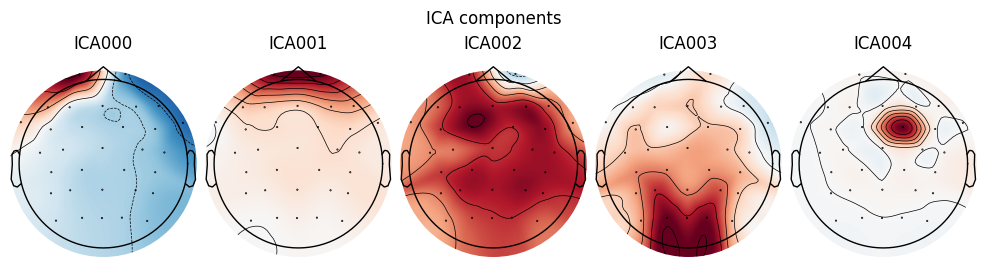

ICA applied to remove artifacts.
Created an SSP operator (subspace dimension = 1)
1 projection items activated
SSP projectors applied...
EOG regression applied.
Using threshold: 0.44 for CTPS ECG detection
Using channel Fp1 to identify heart beats.
Setting up band-pass filter from 8 - 16 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 8.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 7.75 Hz)
- Upper passband edge: 16.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 16.25 Hz)
- Filter length: 1280 samples (10.000 s)

Number of ECG events detected : 1101 (average pulse 60 / min.)
Not setting metadata
1101 matching events found
No baseline correction applied
Created an SSP operator (subspace dimension = 1)
1 projection items activated
Using data from preloaded Raw for 1101 events 

TypeError: annotate_amplitude() got multiple values for argument 'peak'

In [2]:
import mne
from mne.preprocessing import ICA, EOGRegression

# Read your EDF file
raw = raw = mne.io.read_raw_edf(
    r'EDF+\254362\254362.edf',
    #eog=['Fp1', 'Fp2'], # Define eog channels!  I suggest trying making a copy of these as eog1 and eog2 ##NOTE: YOU MUST watch the capitalization!
    misc=None, # List of channel names to be considered as miscellaneous (MISC) channels.
    stim_channel=None,  # Set to None if you don't have a stim channel
    exclude=['TimestampS', 'TimestampMs', 'OrTimestampS', 'OrTimestampMs', 'Counter', 'Interpolated', 'HighBitFlex', 'SaturationFlag', 'RawCq', 'Battery', 'BatteryPercent', 'MarkerHardware', 'CQ.Cz', 'CQ.Fz', 'CQ.Fp1', 'CQ.F7', 'CQ.F3', 'CQ.FC1', 'CQ.C3', 'CQ.FC5', 'CQ.FT9', 'CQ.T7', 'CQ.CP5', 'CQ.CP1', 'CQ.P3', 'CQ.P7', 'CQ.PO9', 'CQ.O1', 'CQ.Pz', 'CQ.Oz', 'CQ.O2', 'CQ.PO10', 'CQ.P8', 'CQ.P4', 'CQ.CP2', 'CQ.CP6', 'CQ.T8', 'CQ.FT10', 'CQ.FC6', 'CQ.C4', 'CQ.FC2', 'CQ.F4', 'CQ.F8', 'CQ.Fp2', 'CQ.Overall', 'EQ.SampleRateQua', 'EQ.OVERALL', 'EQ.Cz', 'EQ.Fz', 'EQ.Fp1', 'EQ.F7', 'EQ.F3', 'EQ.FC1', 'EQ.C3', 'EQ.FC5', 'EQ.FT9', 'EQ.T7', 'EQ.CP5', 'EQ.CP1', 'EQ.P3', 'EQ.P7', 'EQ.PO9', 'EQ.O1', 'EQ.Pz', 'EQ.Oz', 'EQ.O2', 'EQ.PO10', 'EQ.P8', 'EQ.P4', 'EQ.CP2', 'EQ.CP6', 'EQ.T8', 'EQ.FT10', 'EQ.FC6', 'EQ.C4', 'EQ.FC2', 'EQ.F4', 'EQ.F8', 'EQ.Fp2', 'MOT.TimestampS', 'MOT.TimestampMs', 'MOT.OrTimestampS', 'MOT.OrTimestampM', 'MOT.CounterMems', 'MOT.Interpolated', 'MOT.Q0', 'MOT.Q1', 'MOT.Q2', 'MOT.Q3', 'MOT.AccX', 'MOT.AccY', 'MOT.AccZ', 'MOT.MagX', 'MOT.MagY', 'MOT.MagZ'],  # Exclude channels you don't want
    preload=True,  # Preload data into memory to speed things up
    infer_types=True,  # Infer channel types from names
    verbose=True  # Set verbosity / output messages
    )


print(f"Raw data loaded. Number of channels: {len(raw.ch_names)}, Sampling frequency: {raw.info['sfreq']} Hz")

# Select EEG channels
eeg_channels = ['Cz', 'Fz', 'Fp1', 'F7', 'F3', 'FC1', 'C3', 'FC5', 'FT9', 'T7', 'CP5', 'CP1', 'P3', 'P7', 'PO9', 'O1', 'Pz', 'Oz', 'O2', 'PO10', 'P8', 'P4', 'CP2', 'CP6', 'T8', 'FT10', 'FC6', 'C4', 'FC2', 'F4', 'F8', 'Fp2']
raw.pick_channels(eeg_channels)
print(f"Selected EEG channels: {eeg_channels}")

# Set montage
montage = mne.channels.make_standard_montage('standard_1020')
raw.set_montage(montage, on_missing='ignore')
print("Standard 10-20 montage applied.")

# Apply preprocessing steps
raw.set_eeg_reference('average', projection=True)
raw.filter(l_freq=1, h_freq=40)
print("Applied average reference and band-pass filter (1 - 40 Hz).")

# Apply ICA to remove artifacts
ica = ICA(n_components=5, random_state=97, max_iter=800)
ica.fit(raw)
ica.plot_components()
print("ICA applied to remove artifacts.")

# EOG regression
eogRegression = EOGRegression(picks_artifact='Fp1')
eogRegression.fit(raw)
eogCorrected = eogRegression.apply(raw.copy())
print("EOG regression applied.")

# Find ECG-related components and exclude
ecg_indices, ecg_scores = ica.find_bads_ecg(raw, ch_name='Fp1')
ica.exclude = ecg_indices
print(f"Found and excluded ECG-related components: {ecg_indices}")

# Apply ICA solution to clean data
raw_clean = ica.apply(raw.copy())
print("ICA solution applied to obtain cleaned data.")

# Annotate amplitude thresholds
peak_threshold = 0.0004
flat_threshold = 0.0003
bad_percent_threshold = 1
min_duration_threshold = 0.005
print(f"Annotating amplitude with thresholds: peak={peak_threshold}, flat={flat_threshold}, bad_percent={bad_percent_threshold}, min_duration={min_duration_threshold}")
annotations, segments = mne.preprocessing.annotate_amplitude(raw, 'test',peak=peak_threshold, flat=flat_threshold,
                                                             bad_percent=bad_percent_threshold,
                                                             min_duration=min_duration_threshold,
                                                             picks=eeg_channels, verbose=True)
print(f"Segments found: {segments}")

# Ensure segments are correctly formatted
annot_segments = []
if segments is not None:
    for seg in segments:
        if isinstance(seg, dict) and 'onset' in seg and 'duration' in seg:
            annot_segments.append((seg['onset'], seg['duration'], 'bad'))

# Create Annotations object and assign to raw data
annot = mne.Annotations(annot_segments, raw.info['sfreq'], orig_time=raw.annotations.orig_time)
raw.set_annotations(annot)
print("Annotations created and assigned to raw data.")

# Plot raw and cleaned data for comparison
raw.plot(title='Raw EEG Data')
raw_clean.plot(title='Cleaned EEG Data')
print("Plotted raw and cleaned EEG data.")


Extracting EDF parameters from r:\FINAL_EDF_REPO\EDF_analysis\Archive\EDF+\254362\254362.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 143999  =      0.000 ...  1124.992 secs...
Raw data loaded. Number of channels: 32, Sampling frequency: 128.0 Hz
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Selected EEG channels: ['Cz', 'Fz', 'Fp1', 'F7', 'F3', 'FC1', 'C3', 'FC5', 'FT9', 'T7', 'CP5', 'CP1', 'P3', 'P7', 'PO9', 'O1', 'Pz', 'Oz', 'O2', 'PO10', 'P8', 'P4', 'CP2', 'CP6', 'T8', 'FT10', 'FC6', 'C4', 'FC2', 'F4', 'F8', 'Fp2']
Standard 10-20 montage applied.
EEG channel type selected for re-referencing
Adding average EEG reference projection.
1 projection items deactivated
Average reference projection was added, but has not been applied yet. Use the apply_proj method to apply it.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s


Selecting by number: 5 components
Fitting ICA took 1.4s.


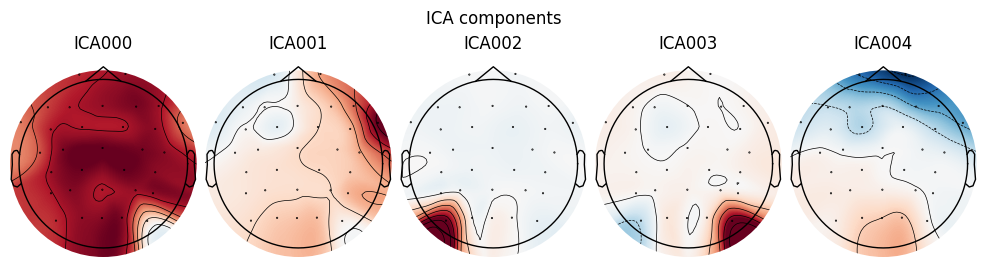

ICA applied to remove artifacts.
Created an SSP operator (subspace dimension = 1)
1 projection items activated
SSP projectors applied...
EOG regression applied.
Using threshold: 0.44 for CTPS ECG detection
Using channel Fp1 to identify heart beats.
Setting up band-pass filter from 8 - 16 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 8.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 7.75 Hz)
- Upper passband edge: 16.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 16.25 Hz)
- Filter length: 1280 samples (10.000 s)

Number of ECG events detected : 1605 (average pulse 85.6 / min.)
Not setting metadata
1605 matching events found
No baseline correction applied
Created an SSP operator (subspace dimension = 1)
1 projection items activated
Using data from preloaded Raw for 1605 event

In [1]:
import mne
from mne.preprocessing import ICA, EOGRegression

# Read your EDF file
raw = raw = mne.io.read_raw_edf(
    r'EDF+\254362\254362.edf',
    #eog=['Fp1', 'Fp2'], # Define eog channels!  I suggest trying making a copy of these as eog1 and eog2 ##NOTE: YOU MUST watch the capitalization!
    misc=None, # List of channel names to be considered as miscellaneous (MISC) channels.
    stim_channel=None,  # Set to None if you don't have a stim channel
    exclude=['TimestampS', 'TimestampMs', 'OrTimestampS', 'OrTimestampMs', 'Counter', 'Interpolated', 'HighBitFlex', 'SaturationFlag', 'RawCq', 'Battery', 'BatteryPercent', 'MarkerHardware', 'CQ.Cz', 'CQ.Fz', 'CQ.Fp1', 'CQ.F7', 'CQ.F3', 'CQ.FC1', 'CQ.C3', 'CQ.FC5', 'CQ.FT9', 'CQ.T7', 'CQ.CP5', 'CQ.CP1', 'CQ.P3', 'CQ.P7', 'CQ.PO9', 'CQ.O1', 'CQ.Pz', 'CQ.Oz', 'CQ.O2', 'CQ.PO10', 'CQ.P8', 'CQ.P4', 'CQ.CP2', 'CQ.CP6', 'CQ.T8', 'CQ.FT10', 'CQ.FC6', 'CQ.C4', 'CQ.FC2', 'CQ.F4', 'CQ.F8', 'CQ.Fp2', 'CQ.Overall', 'EQ.SampleRateQua', 'EQ.OVERALL', 'EQ.Cz', 'EQ.Fz', 'EQ.Fp1', 'EQ.F7', 'EQ.F3', 'EQ.FC1', 'EQ.C3', 'EQ.FC5', 'EQ.FT9', 'EQ.T7', 'EQ.CP5', 'EQ.CP1', 'EQ.P3', 'EQ.P7', 'EQ.PO9', 'EQ.O1', 'EQ.Pz', 'EQ.Oz', 'EQ.O2', 'EQ.PO10', 'EQ.P8', 'EQ.P4', 'EQ.CP2', 'EQ.CP6', 'EQ.T8', 'EQ.FT10', 'EQ.FC6', 'EQ.C4', 'EQ.FC2', 'EQ.F4', 'EQ.F8', 'EQ.Fp2', 'MOT.TimestampS', 'MOT.TimestampMs', 'MOT.OrTimestampS', 'MOT.OrTimestampM', 'MOT.CounterMems', 'MOT.Interpolated', 'MOT.Q0', 'MOT.Q1', 'MOT.Q2', 'MOT.Q3', 'MOT.AccX', 'MOT.AccY', 'MOT.AccZ', 'MOT.MagX', 'MOT.MagY', 'MOT.MagZ'],  # Exclude channels you don't want
    preload=True,  # Preload data into memory to speed things up
    infer_types=True,  # Infer channel types from names
    verbose=True  # Set verbosity / output messages
    )


print(f"Raw data loaded. Number of channels: {len(raw.ch_names)}, Sampling frequency: {raw.info['sfreq']} Hz")

# Select EEG channels
eeg_channels = ['Cz', 'Fz', 'Fp1', 'F7', 'F3', 'FC1', 'C3', 'FC5', 'FT9', 'T7', 'CP5', 'CP1', 'P3', 'P7', 'PO9', 'O1', 'Pz', 'Oz', 'O2', 'PO10', 'P8', 'P4', 'CP2', 'CP6', 'T8', 'FT10', 'FC6', 'C4', 'FC2', 'F4', 'F8', 'Fp2']
raw.pick_channels(eeg_channels)
print(f"Selected EEG channels: {eeg_channels}")

# Set montage
montage = mne.channels.make_standard_montage('standard_1020')
raw.set_montage(montage, on_missing='ignore')
print("Standard 10-20 montage applied.")

# Apply preprocessing steps
raw.set_eeg_reference('average', projection=True)
raw.filter(l_freq=1, h_freq=40)
print("Applied average reference and band-pass filter (1 - 40 Hz).")

# Apply ICA to remove artifacts
ica = ICA(n_components=5, random_state=97, max_iter=800)
ica.fit(raw)
ica.plot_components()
print("ICA applied to remove artifacts.")

# EOG regression
eogRegression = EOGRegression(picks_artifact='Fp1')
eogRegression.fit(raw)
eogCorrected = eogRegression.apply(raw.copy())
print("EOG regression applied.")

# Find ECG-related components and exclude
ecg_indices, ecg_scores = ica.find_bads_ecg(raw, ch_name='Fp1')
ica.exclude = ecg_indices
print(f"Found and excluded ECG-related components: {ecg_indices}")

# Apply ICA solution to clean data
raw_clean = ica.apply(raw.copy())
print("ICA solution applied to obtain cleaned data.")

# Annotate amplitude thresholds
peak_threshold = 0.0004
flat_threshold = 0.0003
bad_percent_threshold = 1
min_duration_threshold = 0.005
print(f"Annotating amplitude with thresholds: peak={peak_threshold}, flat={flat_threshold}, bad_percent={bad_percent_threshold}, min_duration={min_duration_threshold}")
annotations, segments = mne.preprocessing.annotate_amplitude(raw, peak=peak_threshold, flat=flat_threshold,
                                                             bad_percent=bad_percent_threshold,
                                                             min_duration=min_duration_threshold,
                                                             picks=eeg_channels, verbose=True)
print(f"Segments found: {segments}")

# Ensure segments are correctly formatted
annot_segments = []
if segments is not None:
    for seg in segments:
        if isinstance(seg, dict) and 'onset' in seg and 'duration' in seg:
            annot_segments.append((seg['onset'], seg['duration'], 'bad'))

# Create Annotations object and assign to raw data
annot_onset = [seg[0] for seg in annot_segments]
annot_duration = [seg[1] for seg in annot_segments]
annot_description = [seg[2] for seg in annot_segments]
annot = mne.Annotations(annot_onset, annot_duration, annot_description, orig_time=raw.annotations.orig_time)
raw.set_annotations(annot)
print("Annotations created and assigned to raw data.")

# # Plot raw and cleaned data for comparison
# raw.plot(title='Raw EEG Data')
# raw_clean.plot(title='Cleaned EEG Data')
# print("Plotted raw and cleaned EEG data.")


Extracting EDF parameters from r:\FINAL_EDF_REPO\EDF_analysis\Archive\EDF+\254362\254362.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 143999  =      0.000 ...  1124.992 secs...
Raw data loaded. Number of channels: 32, Sampling frequency: 128.0 Hz
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Selected EEG channels: ['Cz', 'Fz', 'Fp1', 'F7', 'F3', 'FC1', 'C3', 'FC5', 'FT9', 'T7', 'CP5', 'CP1', 'P3', 'P7', 'PO9', 'O1', 'Pz', 'Oz', 'O2', 'PO10', 'P8', 'P4', 'CP2', 'CP6', 'T8', 'FT10', 'FC6', 'C4', 'FC2', 'F4', 'F8', 'Fp2']
Standard 10-20 montage applied.
EEG channel type selected for re-referencing
Adding average EEG reference projection.
1 projection items deactivated
Average reference projection was added, but has not been applied yet. Use the apply_proj method to apply it.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s


Selecting by number: 5 components
Fitting ICA took 1.3s.


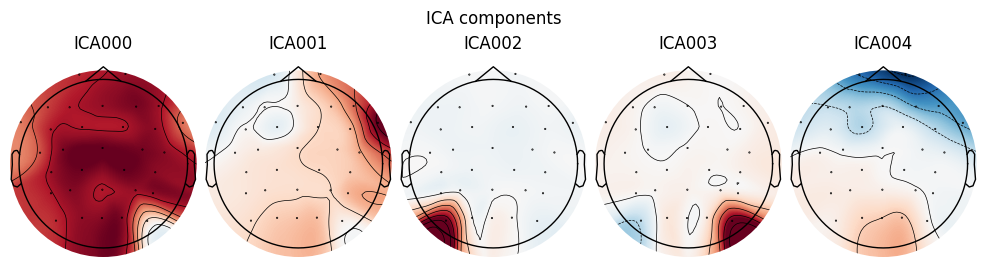

ICA applied to remove artifacts.
Created an SSP operator (subspace dimension = 1)
1 projection items activated
SSP projectors applied...
EOG regression applied.
Using threshold: 0.44 for CTPS ECG detection
Using channel Fp1 to identify heart beats.
Setting up band-pass filter from 8 - 16 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 8.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 7.75 Hz)
- Upper passband edge: 16.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 16.25 Hz)
- Filter length: 1280 samples (10.000 s)

Number of ECG events detected : 1605 (average pulse 85.6 / min.)
Not setting metadata
1605 matching events found
No baseline correction applied
Created an SSP operator (subspace dimension = 1)
1 projection items activated
Using data from preloaded Raw for 1605 event

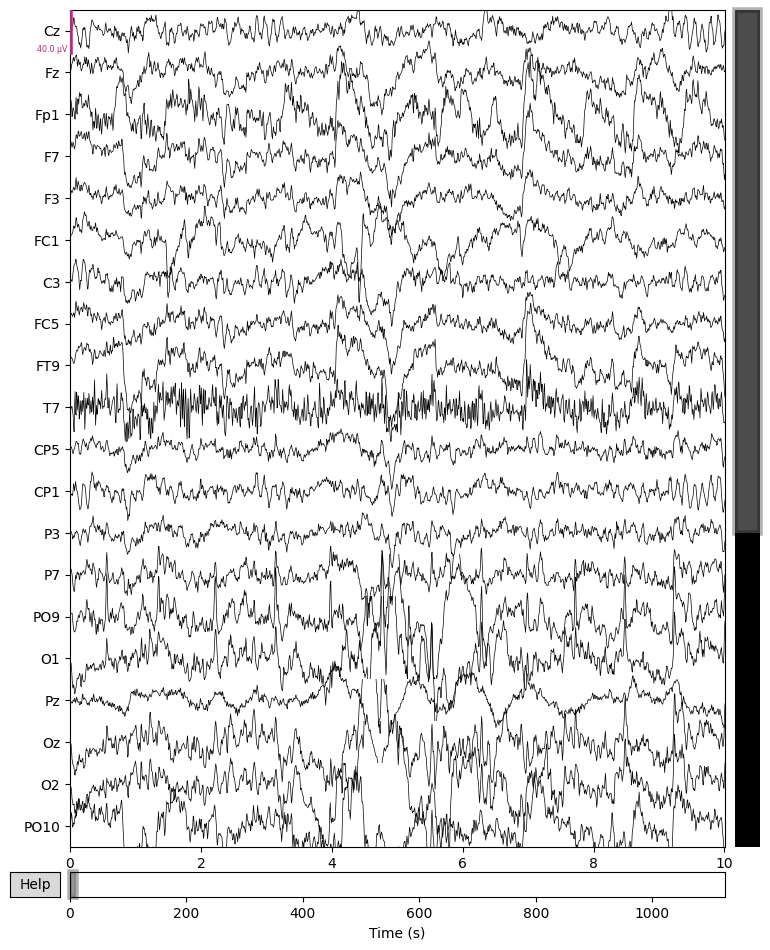

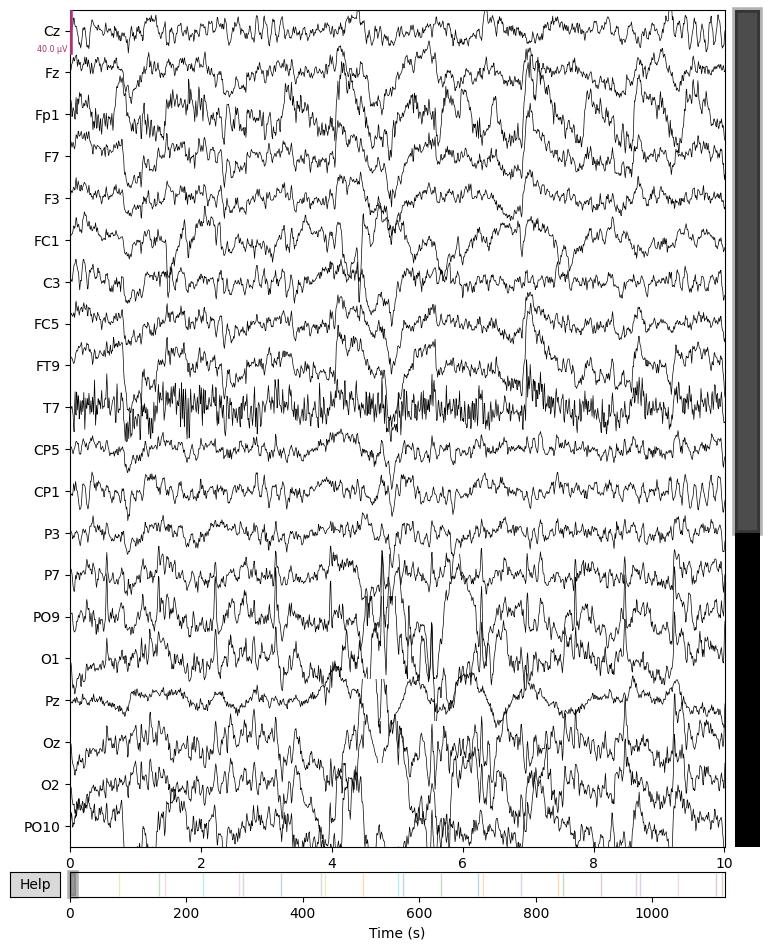

Plotted raw and cleaned EEG data.


In [2]:
import mne
from mne.preprocessing import ICA, EOGRegression

# Read your EDF file
raw = raw = mne.io.read_raw_edf(
    r'EDF+\254362\254362.edf',
    #eog=['Fp1', 'Fp2'], # Define eog channels!  I suggest trying making a copy of these as eog1 and eog2 ##NOTE: YOU MUST watch the capitalization!
    misc=None, # List of channel names to be considered as miscellaneous (MISC) channels.
    stim_channel=None,  # Set to None if you don't have a stim channel
    exclude=['TimestampS', 'TimestampMs', 'OrTimestampS', 'OrTimestampMs', 'Counter', 'Interpolated', 'HighBitFlex', 'SaturationFlag', 'RawCq', 'Battery', 'BatteryPercent', 'MarkerHardware', 'CQ.Cz', 'CQ.Fz', 'CQ.Fp1', 'CQ.F7', 'CQ.F3', 'CQ.FC1', 'CQ.C3', 'CQ.FC5', 'CQ.FT9', 'CQ.T7', 'CQ.CP5', 'CQ.CP1', 'CQ.P3', 'CQ.P7', 'CQ.PO9', 'CQ.O1', 'CQ.Pz', 'CQ.Oz', 'CQ.O2', 'CQ.PO10', 'CQ.P8', 'CQ.P4', 'CQ.CP2', 'CQ.CP6', 'CQ.T8', 'CQ.FT10', 'CQ.FC6', 'CQ.C4', 'CQ.FC2', 'CQ.F4', 'CQ.F8', 'CQ.Fp2', 'CQ.Overall', 'EQ.SampleRateQua', 'EQ.OVERALL', 'EQ.Cz', 'EQ.Fz', 'EQ.Fp1', 'EQ.F7', 'EQ.F3', 'EQ.FC1', 'EQ.C3', 'EQ.FC5', 'EQ.FT9', 'EQ.T7', 'EQ.CP5', 'EQ.CP1', 'EQ.P3', 'EQ.P7', 'EQ.PO9', 'EQ.O1', 'EQ.Pz', 'EQ.Oz', 'EQ.O2', 'EQ.PO10', 'EQ.P8', 'EQ.P4', 'EQ.CP2', 'EQ.CP6', 'EQ.T8', 'EQ.FT10', 'EQ.FC6', 'EQ.C4', 'EQ.FC2', 'EQ.F4', 'EQ.F8', 'EQ.Fp2', 'MOT.TimestampS', 'MOT.TimestampMs', 'MOT.OrTimestampS', 'MOT.OrTimestampM', 'MOT.CounterMems', 'MOT.Interpolated', 'MOT.Q0', 'MOT.Q1', 'MOT.Q2', 'MOT.Q3', 'MOT.AccX', 'MOT.AccY', 'MOT.AccZ', 'MOT.MagX', 'MOT.MagY', 'MOT.MagZ'],  # Exclude channels you don't want
    preload=True,  # Preload data into memory to speed things up
    infer_types=True,  # Infer channel types from names
    verbose=True  # Set verbosity / output messages
    )


print(f"Raw data loaded. Number of channels: {len(raw.ch_names)}, Sampling frequency: {raw.info['sfreq']} Hz")

# Select EEG channels
eeg_channels = ['Cz', 'Fz', 'Fp1', 'F7', 'F3', 'FC1', 'C3', 'FC5', 'FT9', 'T7', 'CP5', 'CP1', 'P3', 'P7', 'PO9', 'O1', 'Pz', 'Oz', 'O2', 'PO10', 'P8', 'P4', 'CP2', 'CP6', 'T8', 'FT10', 'FC6', 'C4', 'FC2', 'F4', 'F8', 'Fp2']
raw.pick_channels(eeg_channels)
print(f"Selected EEG channels: {eeg_channels}")

# Set montage
montage = mne.channels.make_standard_montage('standard_1020')
raw.set_montage(montage, on_missing='ignore')
print("Standard 10-20 montage applied.")

# Apply preprocessing steps
raw.set_eeg_reference('average', projection=True)
raw.filter(l_freq=1, h_freq=40)
print("Applied average reference and band-pass filter (1 - 40 Hz).")

# Apply ICA to remove artifacts
ica = ICA(n_components=5, random_state=97, max_iter=800)
ica.fit(raw)
ica.plot_components()
print("ICA applied to remove artifacts.")

# EOG regression
eogRegression = EOGRegression(picks_artifact='Fp1')
eogRegression.fit(raw)
eogCorrected = eogRegression.apply(raw.copy())
print("EOG regression applied.")

# Find ECG-related components and exclude
ecg_indices, ecg_scores = ica.find_bads_ecg(raw, ch_name='Fp1')
ica.exclude = ecg_indices
print(f"Found and excluded ECG-related components: {ecg_indices}")

# Apply ICA solution to clean data
raw_clean = ica.apply(raw.copy())
print("ICA solution applied to obtain cleaned data.")

# Annotate amplitude thresholds
peak_threshold = 0.0004
flat_threshold = 0.0003
bad_percent_threshold = 1
min_duration_threshold = 0.005
print(f"Annotating amplitude with thresholds: peak={peak_threshold}, flat={flat_threshold}, bad_percent={bad_percent_threshold}, min_duration={min_duration_threshold}")
annotations, segments = mne.preprocessing.annotate_amplitude(raw, peak=peak_threshold, flat=flat_threshold,
                                                             bad_percent=bad_percent_threshold,
                                                             min_duration=min_duration_threshold,
                                                             picks=eeg_channels, verbose=True)
print(f"Segments found: {segments}")

# Ensure segments are correctly formatted
annot_segments = []
if segments is not None:
    for seg in segments:
        if isinstance(seg, dict) and 'onset' in seg and 'duration' in seg:
            annot_segments.append((seg['onset'], seg['duration'], 'bad'))

# Create Annotations object and assign to raw data
annot_onset = [seg[0] for seg in annot_segments]
annot_duration = [seg[1] for seg in annot_segments]
annot_description = [seg[2] for seg in annot_segments]
annot = mne.Annotations(onset=annot_onset, duration=annot_duration, description=annot_description, orig_time=raw.annotations.orig_time)
raw.set_annotations(annot)
print("Annotations created and assigned to raw data.")

# Plot raw and cleaned data for comparison
raw.plot(title='Raw EEG Data')
raw_clean.plot(title='Cleaned EEG Data')
print("Plotted raw and cleaned EEG data.")


Extracting EDF parameters from e:\WEBSITE\EDF_analysis\EDF+\Zacker\Zacker.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 139775  =      0.000 ...  1091.992 secs...
Raw data loaded. Number of channels: 127, Sampling frequency: 128.0 Hz
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Selected EEG channels: ['Cz', 'Fz', 'Fp1', 'F7', 'F3', 'FC1', 'C3', 'FC5', 'FT9', 'T7', 'CP5', 'CP1', 'P3', 'P7', 'PO9', 'O1', 'Pz', 'Oz', 'O2', 'PO10', 'P8', 'P4', 'CP2', 'CP6', 'T8', 'FT10', 'FC6', 'C4', 'FC2', 'F4', 'F8', 'Fp2']
Standard 10-20 montage applied.
EEG channel type selected for re-referencing
Adding average EEG reference projection.
1 projection items deactivated
Average reference projection was added, but has not been applied yet. Use the apply_proj method to apply it.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designi

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s


Selecting by number: 5 components
Fitting ICA took 1.6s.


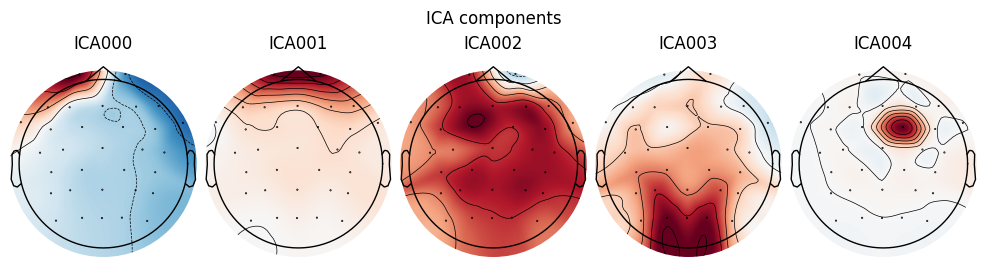

ICA applied to remove artifacts.
Created an SSP operator (subspace dimension = 1)
1 projection items activated
SSP projectors applied...
EOG regression applied.
Using threshold: 0.44 for CTPS ECG detection
Using channel Fp1 to identify heart beats.
Setting up band-pass filter from 8 - 16 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 8.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 7.75 Hz)
- Upper passband edge: 16.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 16.25 Hz)
- Filter length: 1280 samples (10.000 s)

Number of ECG events detected : 1101 (average pulse 60 / min.)
Not setting metadata
1101 matching events found
No baseline correction applied
Created an SSP operator (subspace dimension = 1)
1 projection items activated
Using data from preloaded Raw for 1101 events 

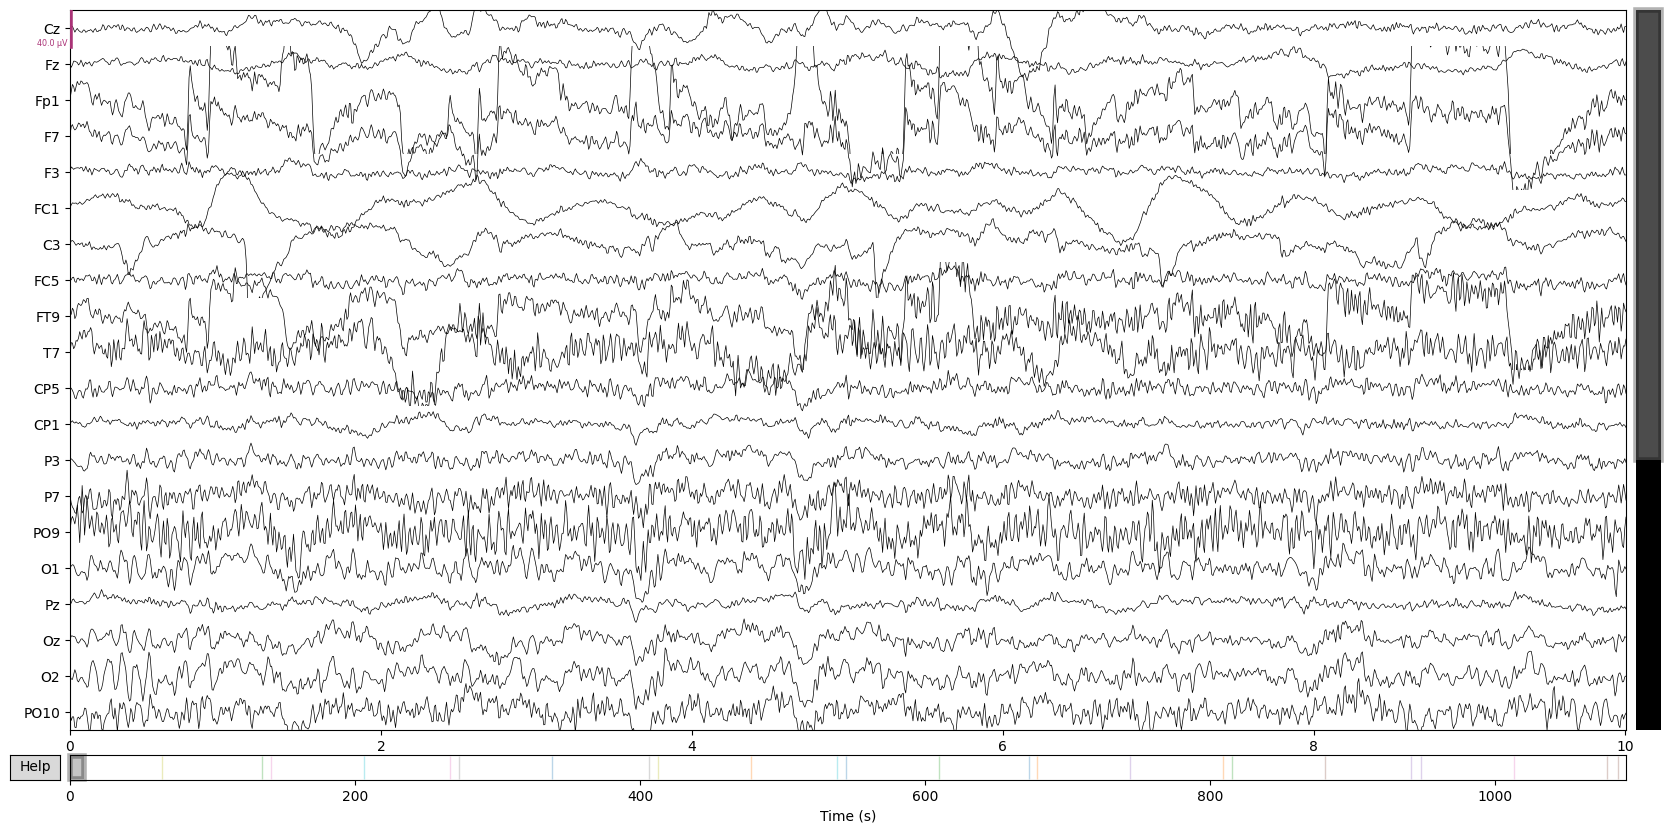

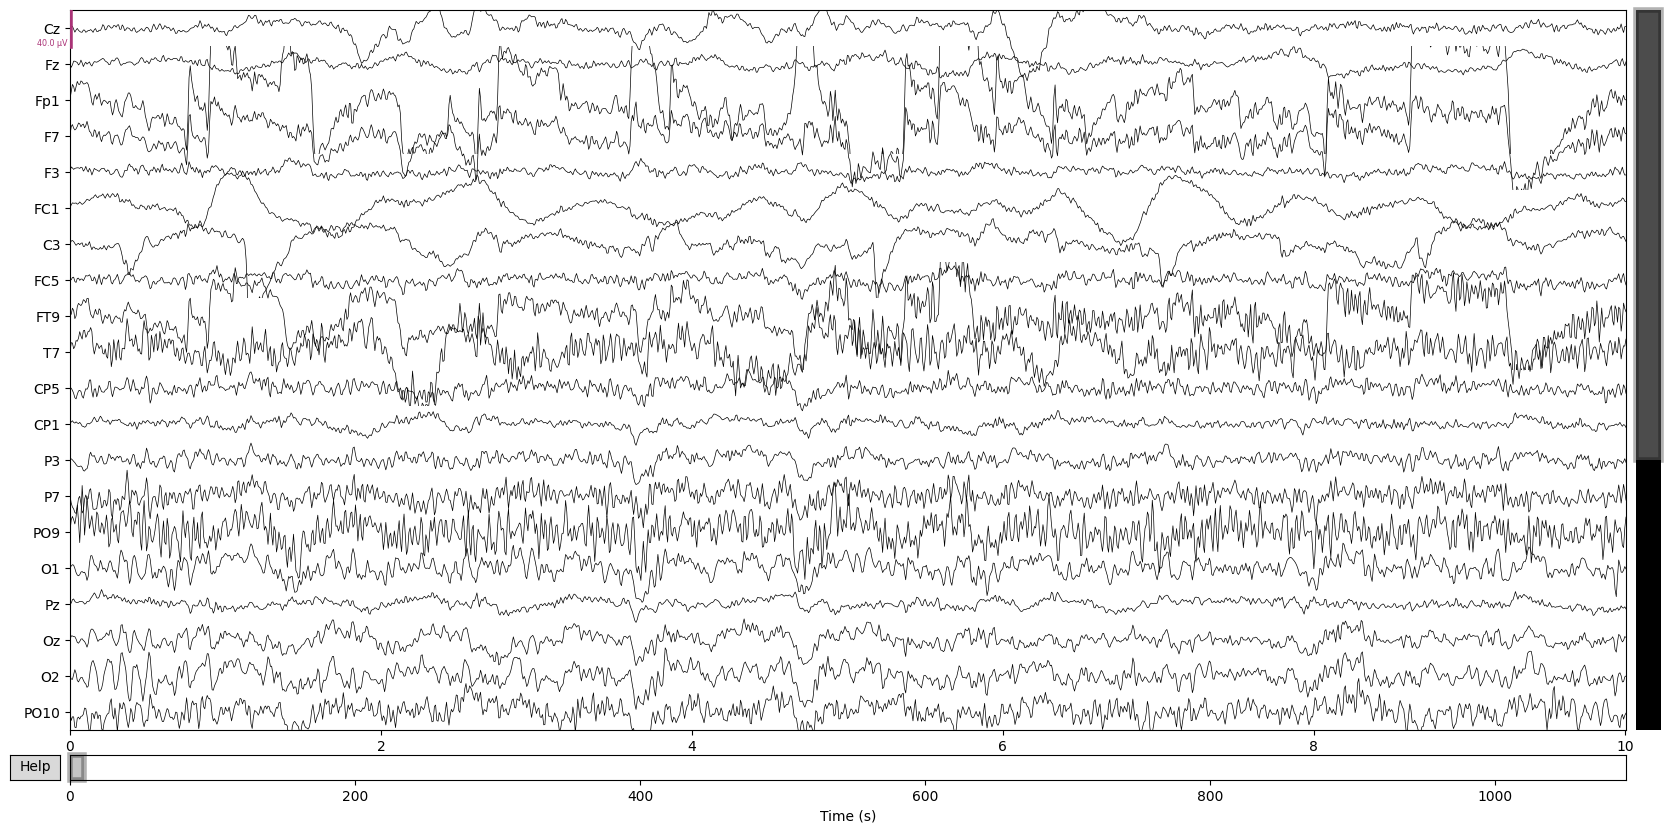

Plotted raw and cleaned EEG data.


In [6]:
import mne
from mne.preprocessing import ICA, EOGRegression

# Read your EDF file
raw = raw = mne.io.read_raw_edf(
    r'EDF+\254362\254362.edf',
    #eog=['Fp1', 'Fp2'], # Define eog channels!  I suggest trying making a copy of these as eog1 and eog2 ##NOTE: YOU MUST watch the capitalization!
    misc=None, # List of channel names to be considered as miscellaneous (MISC) channels.
    stim_channel=None,  # Set to None if you don't have a stim channel
    exclude=['TimestampS', 'TimestampMs', 'OrTimestampS', 'OrTimestampMs', 'Counter', 'Interpolated', 'HighBitFlex', 'SaturationFlag', 'RawCq', 'Battery', 'BatteryPercent', 'MarkerHardware', 'CQ.Cz', 'CQ.Fz', 'CQ.Fp1', 'CQ.F7', 'CQ.F3', 'CQ.FC1', 'CQ.C3', 'CQ.FC5', 'CQ.FT9', 'CQ.T7', 'CQ.CP5', 'CQ.CP1', 'CQ.P3', 'CQ.P7', 'CQ.PO9', 'CQ.O1', 'CQ.Pz', 'CQ.Oz', 'CQ.O2', 'CQ.PO10', 'CQ.P8', 'CQ.P4', 'CQ.CP2', 'CQ.CP6', 'CQ.T8', 'CQ.FT10', 'CQ.FC6', 'CQ.C4', 'CQ.FC2', 'CQ.F4', 'CQ.F8', 'CQ.Fp2', 'CQ.Overall', 'EQ.SampleRateQua', 'EQ.OVERALL', 'EQ.Cz', 'EQ.Fz', 'EQ.Fp1', 'EQ.F7', 'EQ.F3', 'EQ.FC1', 'EQ.C3', 'EQ.FC5', 'EQ.FT9', 'EQ.T7', 'EQ.CP5', 'EQ.CP1', 'EQ.P3', 'EQ.P7', 'EQ.PO9', 'EQ.O1', 'EQ.Pz', 'EQ.Oz', 'EQ.O2', 'EQ.PO10', 'EQ.P8', 'EQ.P4', 'EQ.CP2', 'EQ.CP6', 'EQ.T8', 'EQ.FT10', 'EQ.FC6', 'EQ.C4', 'EQ.FC2', 'EQ.F4', 'EQ.F8', 'EQ.Fp2', 'MOT.TimestampS', 'MOT.TimestampMs', 'MOT.OrTimestampS', 'MOT.OrTimestampM', 'MOT.CounterMems', 'MOT.Interpolated', 'MOT.Q0', 'MOT.Q1', 'MOT.Q2', 'MOT.Q3', 'MOT.AccX', 'MOT.AccY', 'MOT.AccZ', 'MOT.MagX', 'MOT.MagY', 'MOT.MagZ'],  # Exclude channels you don't want
    preload=True,  # Preload data into memory to speed things up
    infer_types=True,  # Infer channel types from names
    verbose=True  # Set verbosity / output messages
    )


print(f"Raw data loaded. Number of channels: {len(raw.ch_names)}, Sampling frequency: {raw.info['sfreq']} Hz")

# Select EEG channels
eeg_channels = ['Cz', 'Fz', 'Fp1', 'F7', 'F3', 'FC1', 'C3', 'FC5', 'FT9', 'T7', 'CP5', 'CP1', 'P3', 'P7', 'PO9', 'O1', 'Pz', 'Oz', 'O2', 'PO10', 'P8', 'P4', 'CP2', 'CP6', 'T8', 'FT10', 'FC6', 'C4', 'FC2', 'F4', 'F8', 'Fp2']
raw.pick_channels(eeg_channels)
print(f"Selected EEG channels: {eeg_channels}")

# Set montage
montage = mne.channels.make_standard_montage('standard_1020')
raw.set_montage(montage, on_missing='ignore')
print("Standard 10-20 montage applied.")

# Apply preprocessing steps
raw.set_eeg_reference('average', projection=True)
raw.filter(l_freq=1, h_freq=40)
print("Applied average reference and band-pass filter (1 - 40 Hz).")

# Apply ICA to remove artifacts
ica = ICA(n_components=5, random_state=97, max_iter=800)
ica.fit(raw)
ica.plot_components()
print("ICA applied to remove artifacts.")

# EOG regression
eogRegression = EOGRegression(picks_artifact='Fp1')
eogRegression.fit(raw)
eogCorrected = eogRegression.apply(raw.copy())
print("EOG regression applied.")

# Find ECG-related components and exclude
ecg_indices, ecg_scores = ica.find_bads_ecg(raw, ch_name='Fp1')
ica.exclude = ecg_indices
print(f"Found and excluded ECG-related components: {ecg_indices}")

# Apply ICA solution to clean data
raw_clean = ica.apply(raw.copy())
print("ICA solution applied to obtain cleaned data.")

# Annotate amplitude thresholds
peak_threshold = 0.0004
flat_threshold = 0.0003
bad_percent_threshold = 1
min_duration_threshold = 0.005
print(f"Annotating amplitude with thresholds: peak={peak_threshold}, flat={flat_threshold}, bad_percent={bad_percent_threshold}, min_duration={min_duration_threshold}")
annotations, segments = mne.preprocessing.annotate_amplitude(raw_clean, peak=peak_threshold, flat=flat_threshold,
                                                             bad_percent=bad_percent_threshold,
                                                             min_duration=min_duration_threshold,
                                                             picks=eeg_channels, verbose=True)
print(f"Segments found: {segments}")

# Ensure segments are correctly formatted
annot_segments = []
if segments is not None:
    for seg in segments:
        if isinstance(seg, dict) and 'onset' in seg and 'duration' in seg:
            annot_segments.append((seg['onset'], seg['duration'], 'bad'))

# Create Annotations object and assign to raw data
annot_onset = [seg[0] for seg in annot_segments]
annot_duration = [seg[1] for seg in annot_segments]
annot_description = [seg[2] for seg in annot_segments]
annot = mne.Annotations(onset=annot_onset, duration=annot_duration, description=annot_description, orig_time=raw.annotations.orig_time)
raw_clean.set_annotations(annot)
print("Annotations created and assigned to cleaned raw data.")

# Plot raw and cleaned data for comparison
raw.plot(title='Raw EEG Data')
raw_clean.plot(title='Cleaned EEG Data')
print("Plotted raw and cleaned EEG data.")


Extracting EDF parameters from e:\WEBSITE\EDF_analysis\EDF+\Zacker\Zacker.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 139775  =      0.000 ...  1091.992 secs...
Raw data loaded. Number of channels: 127, Sampling frequency: 128.0 Hz
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Selected EEG channels: ['Cz', 'Fz', 'Fp1', 'F7', 'F3', 'FC1', 'C3', 'FC5', 'FT9', 'T7', 'CP5', 'CP1', 'P3', 'P7', 'PO9', 'O1', 'Pz', 'Oz', 'O2', 'PO10', 'P8', 'P4', 'CP2', 'CP6', 'T8', 'FT10', 'FC6', 'C4', 'FC2', 'F4', 'F8', 'Fp2']
Standard 10-20 montage applied.
EEG channel type selected for re-referencing
Adding average EEG reference projection.
1 projection items deactivated
Average reference projection was added, but has not been applied yet. Use the apply_proj method to apply it.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designi

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s


Selecting by number: 5 components
Fitting ICA took 0.9s.


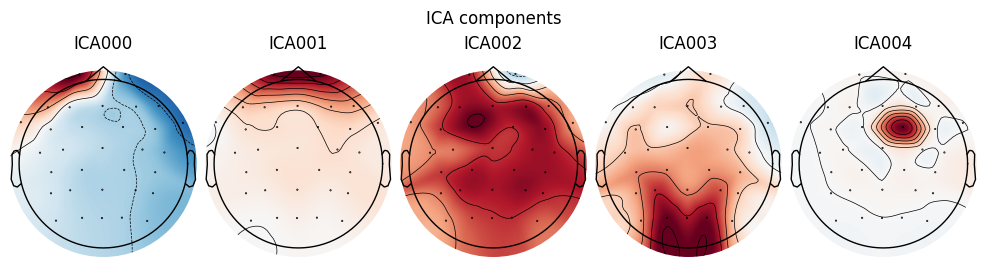

ICA applied to remove artifacts.
Created an SSP operator (subspace dimension = 1)
1 projection items activated
SSP projectors applied...
EOG regression applied.
Applying ICA to Raw instance
    Transforming to ICA space (5 components)
    Zeroing out 0 ICA components
    Projecting back using 32 PCA components
ICA solution applied to obtain cleaned data.
Annotating amplitude with thresholds: peak=0.0004, flat=0.0003, bad_percent=1, min_duration=0.005
Finding segments below or above PTP threshold.
Segments found: ['Cz', 'Fz', 'Fp1', 'F7', 'F3', 'FC1', 'C3', 'FC5', 'FT9', 'T7', 'CP5', 'CP1', 'P3', 'P7', 'PO9', 'O1', 'Pz', 'Oz', 'O2', 'PO10', 'P8', 'P4', 'CP2', 'CP6', 'T8', 'FT10', 'FC6', 'C4', 'FC2', 'F4', 'F8', 'Fp2']
Annotations created and assigned to cleaned raw data.


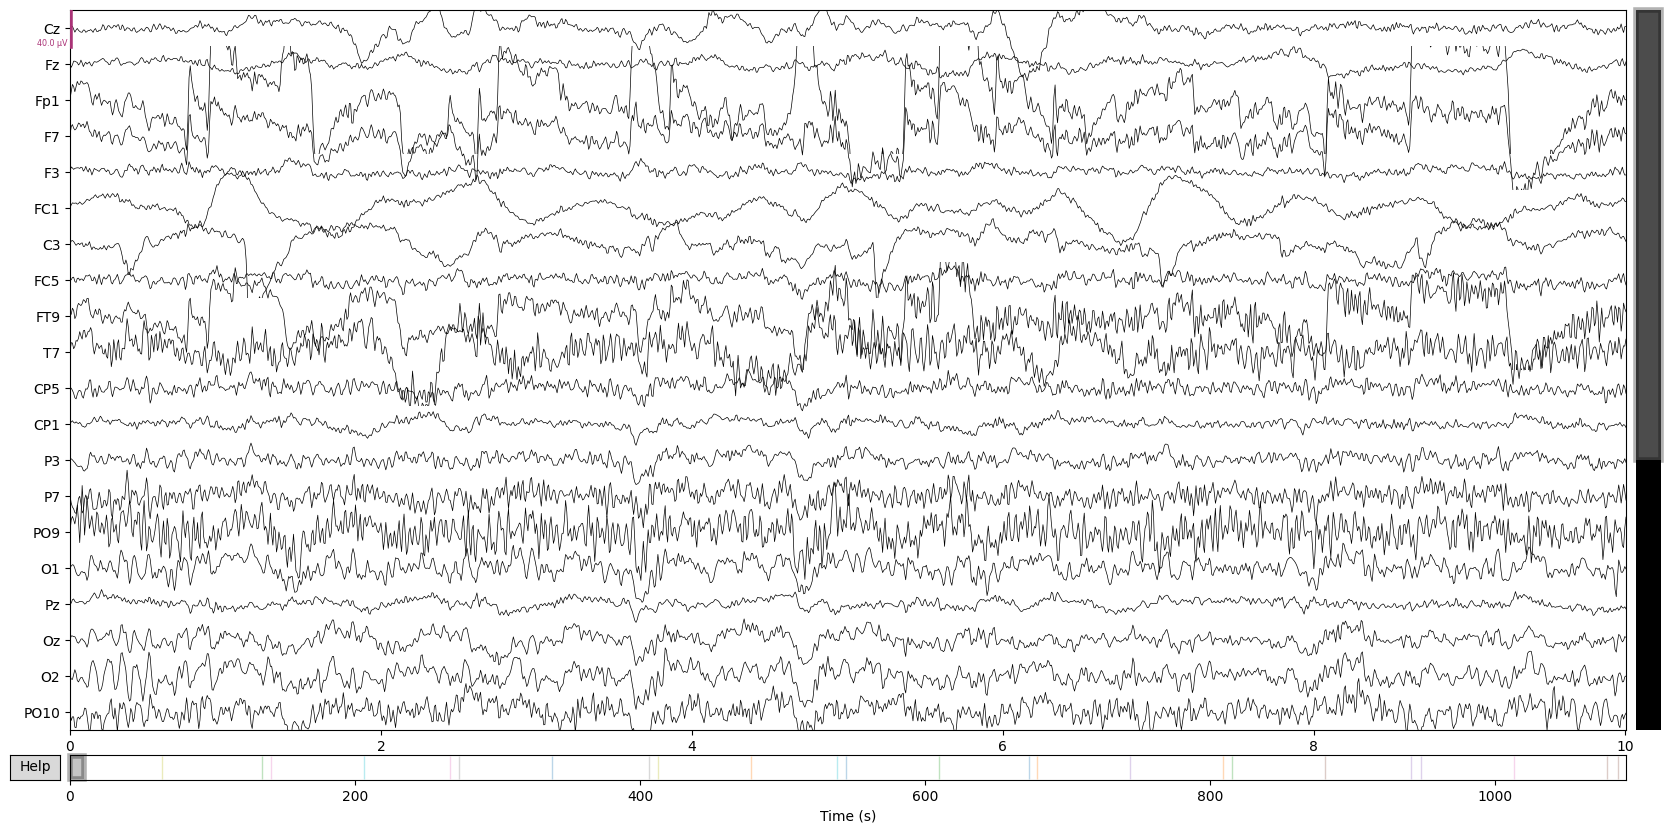

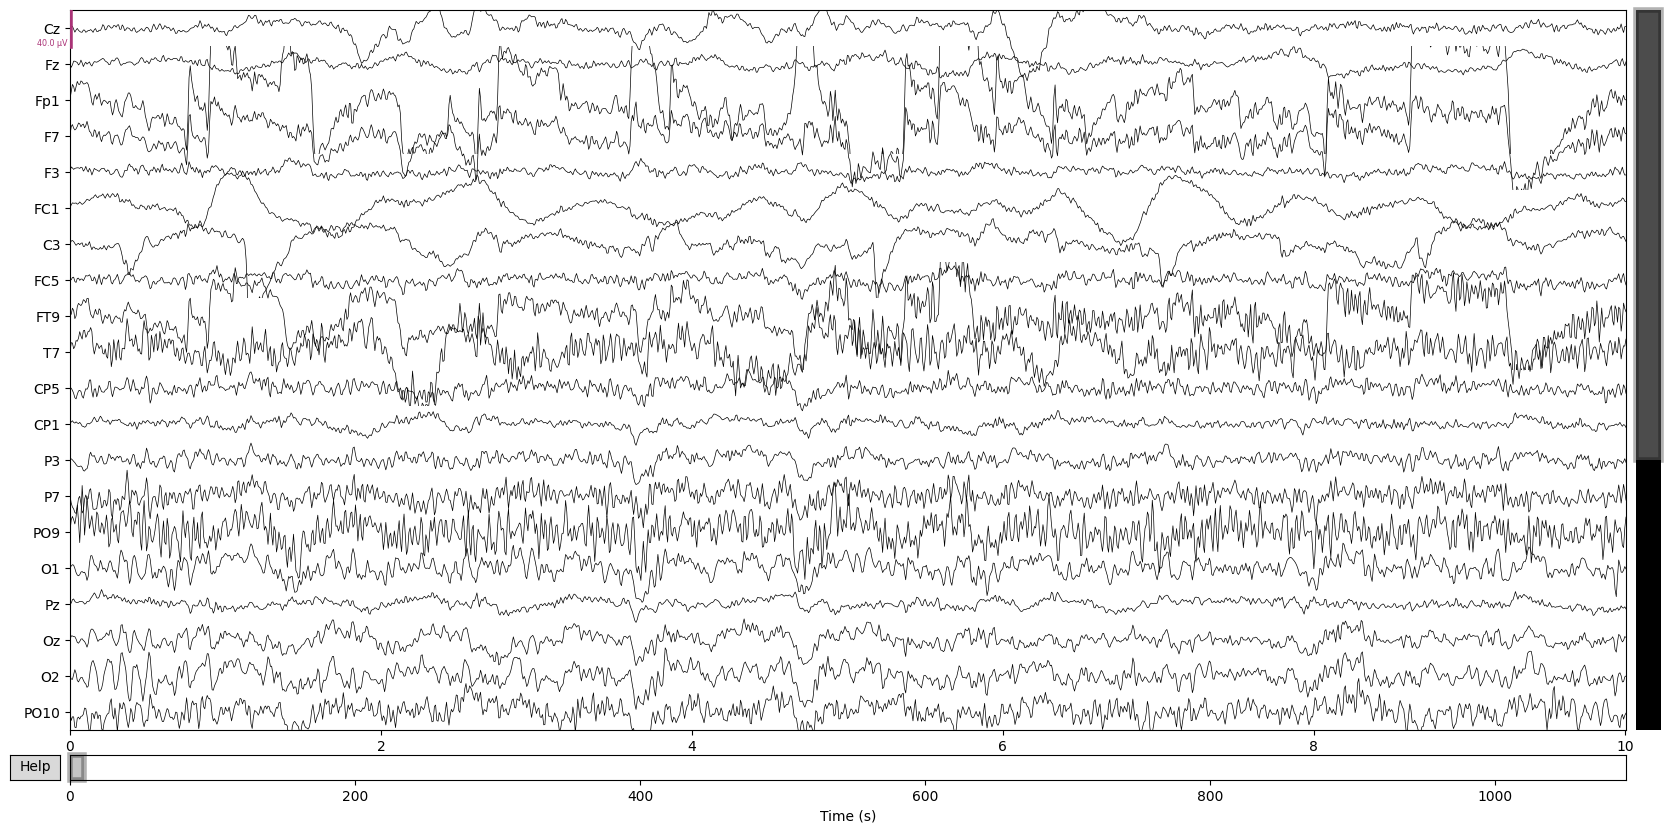

Plotted raw and cleaned EEG data.


In [13]:
import mne
from mne.preprocessing import ICA, EOGRegression

# Read your EDF file
raw = raw = mne.io.read_raw_edf(
    r'EDF+\254362\254362.edf',
    #eog=['Fp1', 'Fp2'], # Define eog channels!  I suggest trying making a copy of these as eog1 and eog2 ##NOTE: YOU MUST watch the capitalization!
    misc=None, # List of channel names to be considered as miscellaneous (MISC) channels.
    stim_channel=None,  # Set to None if you don't have a stim channel
    exclude=['TimestampS', 'TimestampMs', 'OrTimestampS', 'OrTimestampMs', 'Counter', 'Interpolated', 'HighBitFlex', 'SaturationFlag', 'RawCq', 'Battery', 'BatteryPercent', 'MarkerHardware', 'CQ.Cz', 'CQ.Fz', 'CQ.Fp1', 'CQ.F7', 'CQ.F3', 'CQ.FC1', 'CQ.C3', 'CQ.FC5', 'CQ.FT9', 'CQ.T7', 'CQ.CP5', 'CQ.CP1', 'CQ.P3', 'CQ.P7', 'CQ.PO9', 'CQ.O1', 'CQ.Pz', 'CQ.Oz', 'CQ.O2', 'CQ.PO10', 'CQ.P8', 'CQ.P4', 'CQ.CP2', 'CQ.CP6', 'CQ.T8', 'CQ.FT10', 'CQ.FC6', 'CQ.C4', 'CQ.FC2', 'CQ.F4', 'CQ.F8', 'CQ.Fp2', 'CQ.Overall', 'EQ.SampleRateQua', 'EQ.OVERALL', 'EQ.Cz', 'EQ.Fz', 'EQ.Fp1', 'EQ.F7', 'EQ.F3', 'EQ.FC1', 'EQ.C3', 'EQ.FC5', 'EQ.FT9', 'EQ.T7', 'EQ.CP5', 'EQ.CP1', 'EQ.P3', 'EQ.P7', 'EQ.PO9', 'EQ.O1', 'EQ.Pz', 'EQ.Oz', 'EQ.O2', 'EQ.PO10', 'EQ.P8', 'EQ.P4', 'EQ.CP2', 'EQ.CP6', 'EQ.T8', 'EQ.FT10', 'EQ.FC6', 'EQ.C4', 'EQ.FC2', 'EQ.F4', 'EQ.F8', 'EQ.Fp2', 'MOT.TimestampS', 'MOT.TimestampMs', 'MOT.OrTimestampS', 'MOT.OrTimestampM', 'MOT.CounterMems', 'MOT.Interpolated', 'MOT.Q0', 'MOT.Q1', 'MOT.Q2', 'MOT.Q3', 'MOT.AccX', 'MOT.AccY', 'MOT.AccZ', 'MOT.MagX', 'MOT.MagY', 'MOT.MagZ'],  # Exclude channels you don't want
    preload=True,  # Preload data into memory to speed things up
    infer_types=True,  # Infer channel types from names
    verbose=True  # Set verbosity / output messages
    )


print(f"Raw data loaded. Number of channels: {len(raw.ch_names)}, Sampling frequency: {raw.info['sfreq']} Hz")

# Select EEG channels
eeg_channels = ['Cz', 'Fz', 'Fp1', 'F7', 'F3', 'FC1', 'C3', 'FC5', 'FT9', 'T7', 'CP5', 'CP1', 'P3', 'P7', 'PO9', 'O1', 'Pz', 'Oz', 'O2', 'PO10', 'P8', 'P4', 'CP2', 'CP6', 'T8', 'FT10', 'FC6', 'C4', 'FC2', 'F4', 'F8', 'Fp2']
raw.pick_channels(eeg_channels)
print(f"Selected EEG channels: {eeg_channels}")

# Set montage
montage = mne.channels.make_standard_montage('standard_1020')
raw.set_montage(montage, on_missing='ignore')
print("Standard 10-20 montage applied.")

# Apply preprocessing steps
raw.set_eeg_reference('average', projection=True)
raw.filter(l_freq=1, h_freq=40)
print("Applied average reference and band-pass filter (1 - 40 Hz).")

# Apply ICA to remove artifacts
ica = ICA(n_components=5, random_state=97, max_iter=800)
ica.fit(raw)
ica.plot_components()
print("ICA applied to remove artifacts.")

# EOG regression
eogRegression = EOGRegression(picks_artifact='Fp1')
eogRegression.fit(raw)
eogCorrected = eogRegression.apply(raw.copy())
print("EOG regression applied.")

# Apply ICA solution to clean data
raw_clean = ica.apply(raw.copy())
print("ICA solution applied to obtain cleaned data.")

# Annotate amplitude thresholds
peak_threshold = 0.0004
flat_threshold = 0.0003
bad_percent_threshold = 1
min_duration_threshold = 0.005
print(f"Annotating amplitude with thresholds: peak={peak_threshold}, flat={flat_threshold}, bad_percent={bad_percent_threshold}, min_duration={min_duration_threshold}")
annotations, segments = mne.preprocessing.annotate_amplitude(raw_clean, peak=peak_threshold, flat=flat_threshold,
                                                             bad_percent=bad_percent_threshold,
                                                             min_duration=min_duration_threshold,
                                                             picks=eeg_channels, verbose=True)
print(f"Segments found: {segments}")

# Create Annotations object and assign to raw_clean data
if segments is not None and all(isinstance(seg, dict) for seg in segments):
    annot_segments = [(seg['onset'], seg['duration'], 'bad') for seg in segments]
else:
    annot_segments = []

annot_onset = [seg[0] for seg in annot_segments]
annot_duration = [seg[1] for seg in annot_segments]
annot_description = [seg[2] for seg in annot_segments]

annot = mne.Annotations(onset=annot_onset, duration=annot_duration, description=annot_description, orig_time=raw_clean.annotations.orig_time)
raw_clean.set_annotations(annot, emit_warning=True, on_missing='ignore')
print("Annotations created and assigned to cleaned raw data.")

# Plot raw and cleaned data for comparison
raw.plot(title='Raw EEG Data')
raw_clean.plot(title='Cleaned EEG Data')
print("Plotted raw and cleaned EEG data.")


Extracting EDF parameters from e:\WEBSITE\EDF_analysis\EDF+\Zacker\Zacker.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 139775  =      0.000 ...  1091.992 secs...


Raw data loaded. Number of channels: 127, Sampling frequency: 128.0 Hz
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Selected EEG channels: ['Cz', 'Fz', 'Fp1', 'F7', 'F3', 'FC1', 'C3', 'FC5', 'FT9', 'T7', 'CP5', 'CP1', 'P3', 'P7', 'PO9', 'O1', 'Pz', 'Oz', 'O2', 'PO10', 'P8', 'P4', 'CP2', 'CP6', 'T8', 'FT10', 'FC6', 'C4', 'FC2', 'F4', 'F8', 'Fp2']
Standard 10-20 montage applied.
EEG channel type selected for re-referencing
Adding average EEG reference projection.
1 projection items deactivated
Average reference projection was added, but has not been applied yet. Use the apply_proj method to apply it.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transiti

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.1s


Selecting by number: 5 components
Fitting ICA took 1.4s.


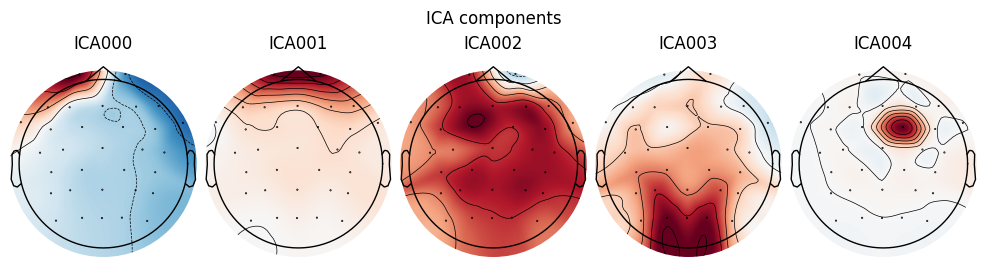

ICA applied to remove artifacts.
Created an SSP operator (subspace dimension = 1)
1 projection items activated
SSP projectors applied...
EOG regression applied.
Applying ICA to Raw instance
    Transforming to ICA space (5 components)
    Zeroing out 0 ICA components
    Projecting back using 32 PCA components
ICA solution applied to obtain cleaned data.
Annotating amplitude with thresholds: peak=0.0004, flat=0.0003, bad_percent=1, min_duration=0.005
Finding segments below or above PTP threshold.
Segments found: ['Cz', 'Fz', 'Fp1', 'F7', 'F3', 'FC1', 'C3', 'FC5', 'FT9', 'T7', 'CP5', 'CP1', 'P3', 'P7', 'PO9', 'O1', 'Pz', 'Oz', 'O2', 'PO10', 'P8', 'P4', 'CP2', 'CP6', 'T8', 'FT10', 'FC6', 'C4', 'FC2', 'F4', 'F8', 'Fp2']
Annotations created and assigned to cleaned raw data.


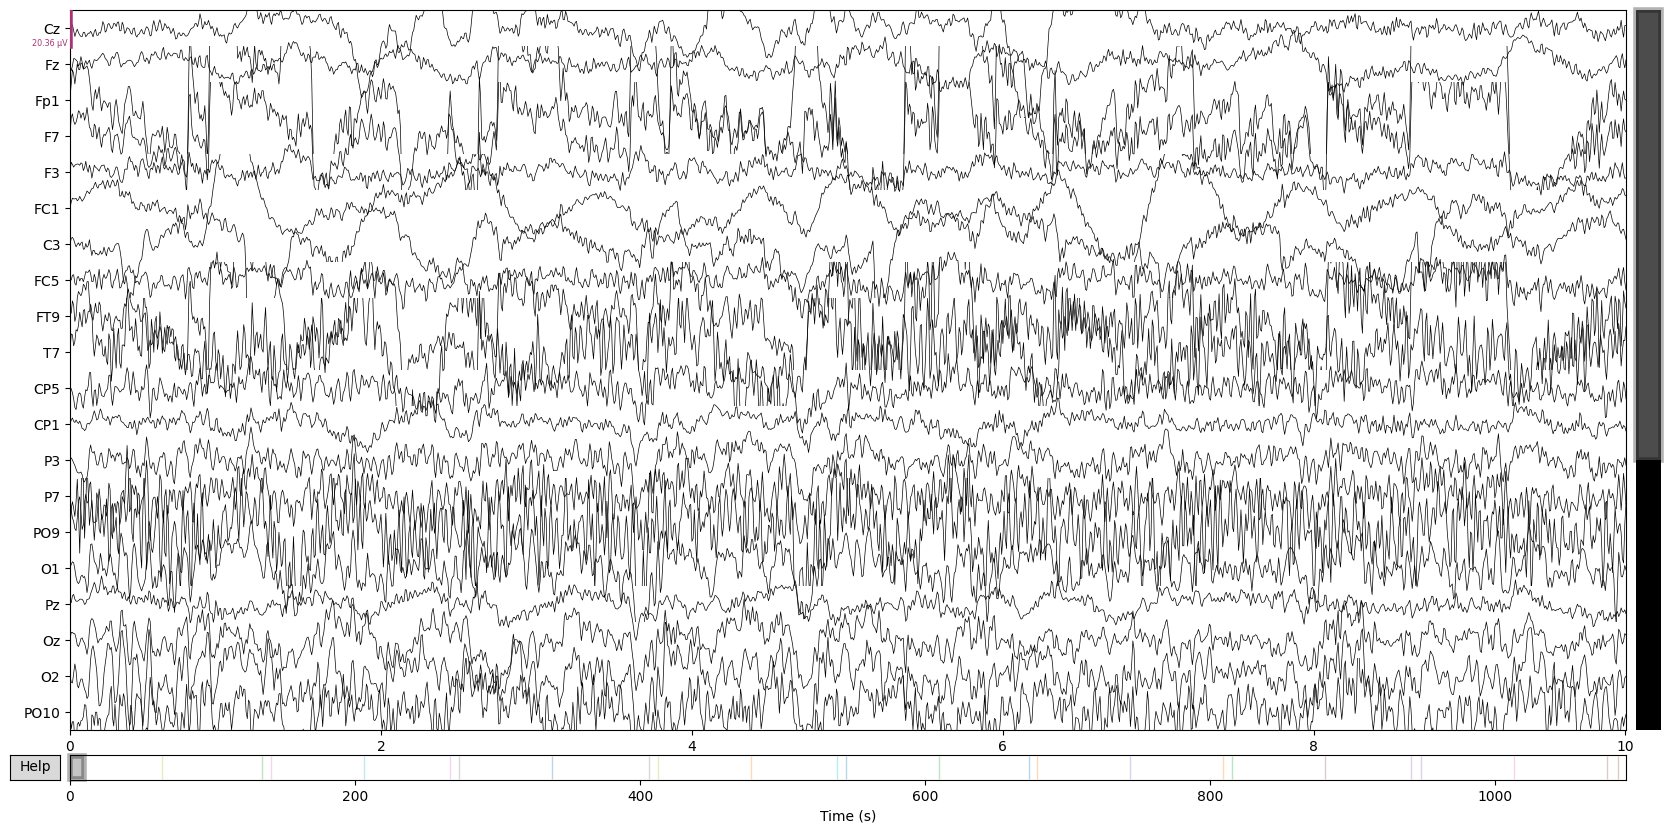

Plotted raw and cleaned EEG data with annotations.


In [10]:
import mne
from mne.preprocessing import ICA, EOGRegression
from mne.io import read_raw_ctf
from mne.preprocessing import annotate_muscle_zscore
import numpy as np
import matplotlib.pyplot as plt


# Read your EDF file
raw = raw = mne.io.read_raw_edf(
    r'EDF+\254362\254362.edf',
    #eog=['Fp1', 'Fp2'], # Define eog channels!  I suggest trying making a copy of these as eog1 and eog2 ##NOTE: YOU MUST watch the capitalization!
    misc=None, # List of channel names to be considered as miscellaneous (MISC) channels.
    stim_channel=None,  # Set to None if you don't have a stim channel
    exclude=['TimestampS', 'TimestampMs', 'OrTimestampS', 'OrTimestampMs', 'Counter', 'Interpolated', 'HighBitFlex', 'SaturationFlag', 'RawCq', 'Battery', 'BatteryPercent', 'MarkerHardware', 'CQ.Cz', 'CQ.Fz', 'CQ.Fp1', 'CQ.F7', 'CQ.F3', 'CQ.FC1', 'CQ.C3', 'CQ.FC5', 'CQ.FT9', 'CQ.T7', 'CQ.CP5', 'CQ.CP1', 'CQ.P3', 'CQ.P7', 'CQ.PO9', 'CQ.O1', 'CQ.Pz', 'CQ.Oz', 'CQ.O2', 'CQ.PO10', 'CQ.P8', 'CQ.P4', 'CQ.CP2', 'CQ.CP6', 'CQ.T8', 'CQ.FT10', 'CQ.FC6', 'CQ.C4', 'CQ.FC2', 'CQ.F4', 'CQ.F8', 'CQ.Fp2', 'CQ.Overall', 'EQ.SampleRateQua', 'EQ.OVERALL', 'EQ.Cz', 'EQ.Fz', 'EQ.Fp1', 'EQ.F7', 'EQ.F3', 'EQ.FC1', 'EQ.C3', 'EQ.FC5', 'EQ.FT9', 'EQ.T7', 'EQ.CP5', 'EQ.CP1', 'EQ.P3', 'EQ.P7', 'EQ.PO9', 'EQ.O1', 'EQ.Pz', 'EQ.Oz', 'EQ.O2', 'EQ.PO10', 'EQ.P8', 'EQ.P4', 'EQ.CP2', 'EQ.CP6', 'EQ.T8', 'EQ.FT10', 'EQ.FC6', 'EQ.C4', 'EQ.FC2', 'EQ.F4', 'EQ.F8', 'EQ.Fp2', 'MOT.TimestampS', 'MOT.TimestampMs', 'MOT.OrTimestampS', 'MOT.OrTimestampM', 'MOT.CounterMems', 'MOT.Interpolated', 'MOT.Q0', 'MOT.Q1', 'MOT.Q2', 'MOT.Q3', 'MOT.AccX', 'MOT.AccY', 'MOT.AccZ', 'MOT.MagX', 'MOT.MagY', 'MOT.MagZ'],  # Exclude channels you don't want
    preload=True,  # Preload data into memory to speed things up
    infer_types=True,  # Infer channel types from names
    verbose=True  # Set verbosity / output messages
    )


print(f"Raw data loaded. Number of channels: {len(raw.ch_names)}, Sampling frequency: {raw.info['sfreq']} Hz")

# Select EEG channels
eeg_channels = ['Cz', 'Fz', 'Fp1', 'F7', 'F3', 'FC1', 'C3', 'FC5', 'FT9', 'T7', 'CP5', 'CP1', 'P3', 'P7', 'PO9', 'O1', 'Pz', 'Oz', 'O2', 'PO10', 'P8', 'P4', 'CP2', 'CP6', 'T8', 'FT10', 'FC6', 'C4', 'FC2', 'F4', 'F8', 'Fp2']
raw.pick_channels(eeg_channels)
print(f"Selected EEG channels: {eeg_channels}")

# Set montage
montage = mne.channels.make_standard_montage('standard_1020')
raw.set_montage(montage, on_missing='ignore')
print("Standard 10-20 montage applied.")

# Apply preprocessing steps
raw.set_eeg_reference('average', projection=True)
raw.filter(l_freq=1, h_freq=40)
print("Applied average reference and band-pass filter (1 - 40 Hz).")

# Apply ICA to remove artifacts
ica = ICA(n_components=5, random_state=97, max_iter=800)
ica.fit(raw)
ica.plot_components()
print("ICA applied to remove artifacts.")

# EOG regression
eogRegression = EOGRegression(picks_artifact='Fp1')
eogRegression.fit(raw)
eogCorrected = eogRegression.apply(raw.copy())
print("EOG regression applied.")

# Apply ICA solution to clean data
raw_clean = ica.apply(raw.copy())
print("ICA solution applied to obtain cleaned data.")

# Annotate amplitude thresholds
peak_threshold = 0.0004
flat_threshold = 0.0003
bad_percent_threshold = 1
min_duration_threshold = 0.005
print(f"Annotating amplitude with thresholds: peak={peak_threshold}, flat={flat_threshold}, bad_percent={bad_percent_threshold}, min_duration={min_duration_threshold}")
annotations, segments = mne.preprocessing.annotate_amplitude(raw_clean, peak=peak_threshold, flat=flat_threshold,
                                                             bad_percent=bad_percent_threshold,
                                                             min_duration=min_duration_threshold,
                                                             picks=eeg_channels, verbose=True)
print(f"Segments found: {segments}")

# Create Annotations object and assign to raw_clean data
if segments is not None and all(isinstance(seg, dict) for seg in segments):
    annot_segments = [(seg['onset'], seg['duration'], 'bad') for seg in segments]
else:
    annot_segments = []

annot = mne.Annotations(onset=[seg[0] for seg in annot_segments],
                        duration=[seg[1] for seg in annot_segments],
                        description=[seg[2] for seg in annot_segments],
                        orig_time=raw_clean.annotations.orig_time)
raw_clean.set_annotations(annot, emit_warning=True, on_missing='ignore')
print("Annotations created and assigned to cleaned raw data.")

# Plot raw and cleaned data with annotations
raw.plot(title='Raw EEG Data', scalings='auto', show=True, block=True)
# It breaks at this line!!!: # raw_clean.plot(title='Cleaned EEG Data with Annotations', scalings='auto', show=True, block=True, events=annotations)

print("Plotted raw and cleaned EEG data with annotations.")


In [14]:
from mne.preprocessing import annotate_muscle_zscore
threshold_muscle = 5  # z-score
# Choose one channel type, if there are axial gradiometers and magnetometers,
# select magnetometers as they are more sensitive to muscle activity.
annot_muscle, scores_muscle = annotate_muscle_zscore(
    raw,
    ch_type="eeg",
    threshold=threshold_muscle,
    min_length_good=0.2,
    filter_freq=[1, 63],
)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 63 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)


- Upper passband edge: 63.00 Hz
- Upper transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 63.50 Hz)
- Filter length: 423 samples (3.305 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.1s


Setting up low-pass filter at 4 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 4.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 5.00 Hz)
- Filter length: 213 samples (1.664 s)



In [15]:
fig, ax = plt.subplots()
ax.plot(raw.times, scores_muscle)
ax.axhline(y=threshold_muscle, color="r")
ax.set(xlabel="time, (s)", ylabel="zscore", title="Muscle activity")

[Text(0.5, 0, 'time, (s)'),
 Text(0, 0.5, 'zscore'),
 Text(0.5, 1.0, 'Muscle activity')]

In [3]:
# Example: Assuming raw and order are defined correctly
order = np.arange(0, 10)  # Replace with your valid channel indices
raw.plot(start=5, duration=20, order=order)


NameError: name 'np' is not defined

mne_icalabel module not found. Install it using 'pip install mne-icalabel'.
Extracting EDF parameters from r:\FINAL_EDF_REPO\EDF_analysis\Archive\EDF+\254362\254362.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 143999  =      0.000 ...  1124.992 secs...
Raw data loaded. Number of channels: 32, Sampling frequency: 128.0 Hz
Selected EEG channels: ['Cz', 'Fz', 'Fp1', 'F7', 'F3', 'FC1', 'C3', 'FC5', 'FT9', 'T7', 'CP5', 'CP1', 'P3', 'P7', 'PO9', 'O1', 'Pz', 'Oz', 'O2', 'PO10', 'P8', 'P4', 'CP2', 'CP6', 'T8', 'FT10', 'FC6', 'C4', 'FC2', 'F4', 'F8', 'Fp2']
Standard 10-20 montage applied.
EEG channel type selected for re-referencing
Adding average EEG reference projection.
1 projection items deactivated
Average reference projection was added, but has not been applied yet. Use the apply_proj method to apply it.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
-------------------

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.1s


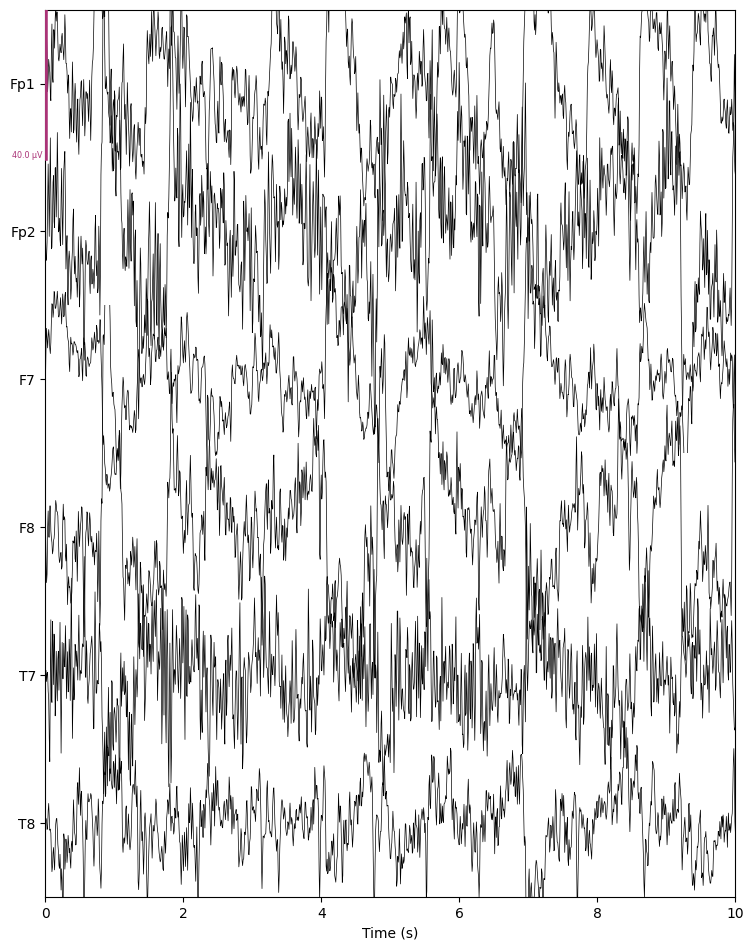

In [4]:
import mne
from mne.preprocessing import ICA

# Ensure mne_icalabel is installed
try:
    from mne_icalabel import label_components
except ModuleNotFoundError:
    print("mne_icalabel module not found. Install it using 'pip install mne-icalabel'.")

# Load raw data
raw = raw = mne.io.read_raw_edf(
    r'EDF+\254362\254362.edf',
    #eog=['Fp1', 'Fp2'], # Define eog channels!  I suggest trying making a copy of these as eog1 and eog2 ##NOTE: YOU MUST watch the capitalization!
    misc=None, # List of channel names to be considered as miscellaneous (MISC) channels.
    stim_channel=None,  # Set to None if you don't have a stim channel
    exclude=['TimestampS', 'TimestampMs', 'OrTimestampS', 'OrTimestampMs', 'Counter', 'Interpolated', 'HighBitFlex', 'SaturationFlag', 'RawCq', 'Battery', 'BatteryPercent', 'MarkerHardware', 'CQ.Cz', 'CQ.Fz', 'CQ.Fp1', 'CQ.F7', 'CQ.F3', 'CQ.FC1', 'CQ.C3', 'CQ.FC5', 'CQ.FT9', 'CQ.T7', 'CQ.CP5', 'CQ.CP1', 'CQ.P3', 'CQ.P7', 'CQ.PO9', 'CQ.O1', 'CQ.Pz', 'CQ.Oz', 'CQ.O2', 'CQ.PO10', 'CQ.P8', 'CQ.P4', 'CQ.CP2', 'CQ.CP6', 'CQ.T8', 'CQ.FT10', 'CQ.FC6', 'CQ.C4', 'CQ.FC2', 'CQ.F4', 'CQ.F8', 'CQ.Fp2', 'CQ.Overall', 'EQ.SampleRateQua', 'EQ.OVERALL', 'EQ.Cz', 'EQ.Fz', 'EQ.Fp1', 'EQ.F7', 'EQ.F3', 'EQ.FC1', 'EQ.C3', 'EQ.FC5', 'EQ.FT9', 'EQ.T7', 'EQ.CP5', 'EQ.CP1', 'EQ.P3', 'EQ.P7', 'EQ.PO9', 'EQ.O1', 'EQ.Pz', 'EQ.Oz', 'EQ.O2', 'EQ.PO10', 'EQ.P8', 'EQ.P4', 'EQ.CP2', 'EQ.CP6', 'EQ.T8', 'EQ.FT10', 'EQ.FC6', 'EQ.C4', 'EQ.FC2', 'EQ.F4', 'EQ.F8', 'EQ.Fp2', 'MOT.TimestampS', 'MOT.TimestampMs', 'MOT.OrTimestampS', 'MOT.OrTimestampM', 'MOT.CounterMems', 'MOT.Interpolated', 'MOT.Q0', 'MOT.Q1', 'MOT.Q2', 'MOT.Q3', 'MOT.AccX', 'MOT.AccY', 'MOT.AccZ', 'MOT.MagX', 'MOT.MagY', 'MOT.MagZ'],  # Exclude channels you don't want
    preload=True,  # Preload data into memory to speed things up
    infer_types=True,  # Infer channel types from names
    verbose=True  # Set verbosity / output messages
    )


print(f"Raw data loaded. Number of channels: {len(raw.ch_names)}, Sampling frequency: {raw.info['sfreq']} Hz")

# Select EEG channels
eeg_channels = ['Cz', 'Fz', 'Fp1', 'F7', 'F3', 'FC1', 'C3', 'FC5', 'FT9', 'T7', 'CP5', 'CP1', 'P3', 'P7', 'PO9', 'O1', 'Pz', 'Oz', 'O2', 'PO10', 'P8', 'P4', 'CP2', 'CP6', 'T8', 'FT10', 'FC6', 'C4', 'FC2', 'F4', 'F8', 'Fp2']
raw.pick(eeg_channels)
print(f"Selected EEG channels: {eeg_channels}")

# Set montage
montage = mne.channels.make_standard_montage('standard_1020')
raw.set_montage(montage, on_missing='ignore')
print("Standard 10-20 montage applied.")

# Apply preprocessing steps
raw.set_eeg_reference('average', projection=True)
raw.filter(l_freq=1, h_freq=40)

# Crop to 60 seconds and drop MEG channels
raw.crop(tmax=60.0).pick_types(eeg=True, stim=True, eog=True)
raw.load_data()

# Manually pick channels that typically show artifacts (adjust as needed)
artifact_picks = mne.pick_channels(raw.ch_names, include=['Fp1', 'Fp2', 'F7', 'F8', 'T7', 'T8'])
if len(artifact_picks) > 0:
    raw.plot(order=artifact_picks, n_channels=len(artifact_picks), show_scrollbars=False)
else:
    print("No channels found to plot.")
